In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
def experiment1_1(gold_df, model_df, model):
    model_results = []

    for comp1_lemma in gold_df['comp1_lemma']: #iterate over gold standard rows and take component1 lemma from each row
        annotation = model_df[model].loc[comp1_lemma].values.item() #see what annotation the LLM gave the lemma
        if annotation == 'JAH' or annotation == 1: #if LLM annotated it as being an occupation, nationality or role
            model_results.append('elative_attribute') #tag the whole row as being an instance of the elative_attribute construction
        else: #if LLM annotated it as NOT being an occupation, nationality or role
            model_results.append('other') #tag the whole row as being an instance of something other than elative_attribute
    return model_results

In [3]:
def experiment1_2(gold_df, model_df, model):
    model_results = []
    model_lemmas = model_df[model].index.values.tolist()

    for comp1_lemma in gold_df['comp1_lemma']: #iterate over gold standard rows and take component1 lemma from each row
        if comp1_lemma in model_lemmas: #if LLM didn't annotate the lemma as being an occupation, nationality or role in experiment1_1
            annotation = model_df[model].loc[comp1_lemma].values.item() #see what annotation the LLM gave the lemma
            if annotation == 'JAH' or annotation == 1: #if LLM annotated it as being a material
                model_results.append('elative_material') #tag the whole row as being an instance of the elative_material construction
            else: #if LLM annotated it as NOT being a material
                model_results.append('other') #tag the whole row as being an instance of something other than elative_material
        else: #if LLM did annotate the lemma as being an occupation, nationality or role in experiment1_1
            model_results.append('other') #tag the whole row as being an instance of something other than elative_material
    return model_results

In [4]:
def experiment1_big(gold_df, model_df, model1, model2):
    model_results = []

    for comp1_lemma in gold_df['comp1_lemma']: #iterate over gold standard rows and take component1 lemma from each row
        annotation_attribute = model_df[model1].loc[comp1_lemma].values.item() #take LLM's annotation for this lemma from experiment1_1 
        if annotation_attribute == 'JAH' or annotation_attribute == 1:  #if LLM annotated the lemma as being an occupation, nationality or role
            model_results.append('elative_attribute') #tag the whole row as being an instance of the elative_attribute construction
        else: #if LLM annotated it as NOT being an occupation, nationality or role
            annotation_material = model_df[model2].loc[comp1_lemma].values.item() #take LLM's annotation for this lemma from experiment1_2
            if annotation_material == 'JAH' or annotation_material == 1: #if LLM annotated it as being a material
                model_results.append('elative_material') #tag the whole row as being an instance of the elative_material construction
            else: #if LLM annotated it as NOT being a material or occupation/nationality/role
                model_results.append('other') #tag the whole row as being an instance of something other than elative_material or elative_attribute
    return model_results

In [5]:
def experiment2_big(gold_df, model_df, model1, model2, column):
    model_results = []

    for value in gold_df[column]: #iterate over gold standard rows and take specified column's value from each row
        annotation_attribute = model_df[model1].loc[value]['elukutse/rahvus/roll'] #take LLM's annotation for this value from elative_attribute experiment
        if annotation_attribute == 'JAH' or annotation_attribute == 1:  #if LLM annotated the value as being an occupation, nationality or role
            model_results.append('elative_attribute') #tag the whole row as being an instance of the elative_attribute construction
        else: #if LLM annotated value as NOT being an occupation, nationality or role
            annotation_material = model_df[model2].loc[value]['materjal'] #take LLM's annotation for this value from elative_material experiment
            if annotation_material == 'JAH' or annotation_material == 1: #if LLM annotated value as being a material
                model_results.append('elative_material') #tag the whole row as being an instance of the elative_material construction
            else: #if LLM annotated value as NOT being a material or occupation/nationality/role
                model_results.append('other') #tag the whole row as being an instance of something other than elative_material or elative_attribute
    return model_results

In [6]:
def experiment3_small(gold_df, model_df, model, column):
    model_results = []

    for value in gold_df[column]: #iterate over gold standard rows and take component1 lemma from each row
        annotation = model_df[model].loc[value]['elukutse/rahvus/roll'] #see what annotation the LLM gave the lemma
        if annotation == 'JAH' or annotation == 1: #if LLM annotated it as being an occupation, nationality or role
            model_results.append('elative_attribute') #tag the whole row as being an instance of the elative_attribute construction
        else: #if LLM annotated it as NOT being an occupation, nationality or role
            model_results.append('other') #tag the whole row as being an instance of something other than elative_attribute
    return model_results

In [7]:
def scores(gold_strandard, model_output):
    print('accuracy', accuracy_score(gold_strandard, model_output))
    print('precision', precision_score(gold_strandard, model_output, average='macro'))
    print('recall', recall_score(gold_strandard, model_output, average='macro'))
    print('f1_macro', f1_score(gold_strandard, model_output, average='macro'))
    print('f1_micro', f1_score(gold_strandard, model_output, average='micro'))
    print('f1_weighted', f1_score(gold_strandard, model_output, average='weighted'))
    print('f1_none', f1_score(gold_strandard, model_output, average=None))

In [8]:
def conf_matrix(gold_strandard, model_output, labels):
    cm = confusion_matrix(gold_strandard, model_output)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()

## Read files in

In [9]:
annotator_1_path = "C:\\Users\\kertu.saul\\OneDrive - Eesti Keele Instituut\\Dokumendid\\doktoritoo\\konstruktikoni_töövoog\\gold_standard\\elative_conx_annotator1_new.xlsx"
annotator_2_path = "C:\\Users\\kertu.saul\\OneDrive - Eesti Keele Instituut\\Dokumendid\\doktoritoo\\konstruktikoni_töövoog\\gold_standard\\elative_conx_annotator2_new.xlsx"
model_results_path = "C:\\Users\\kertu.saul\\OneDrive - Eesti Keele Instituut\\Dokumendid\\doktoritoo\\konstruktikoni_töövoog\\results\\elative_conx_results_june2026_API.xlsx"

annotator_1_df = pd.read_excel(annotator_1_path)
annotator_2_df = pd.read_excel(annotator_2_path)
model_results_df = pd.read_excel(model_results_path, sheet_name=None, index_col = 0)

### Output words that recieved two different annotation labels in the gold standard

In [8]:
#output words that recieved two different annotation classes 
result = (
    annotator_1_df.groupby('comp1_lemma')['manual_annotation']
      .agg(lambda x: list(set(x)))
      .reset_index(name='annotations')
)

# Keep only rows with more than one unique annotation
result = result[result['annotations'].apply(len) > 1]

print(result)

         comp1_lemma                 annotations
7              aasta              [error, other]
25       ameeriklane  [elative_attribute, error]
57          eestlane  [elative_attribute, error]
67            enamik              [error, other]
110             hõbe   [elative_material, error]
126             isik  [elative_attribute, error]
130          jaanuar              [other, error]
151           kallas              [other, error]
160         karistus              [other, error]
177  keskerakondlane  [elative_attribute, error]
188             kivi   [elative_material, error]
192            klass  [elative_attribute, other]
200             koht              [other, error]
259             liha   [elative_material, error]
272              luu   [elative_material, error]
304        miljardär  [elative_attribute, error]
392            plast   [elative_material, error]
394        plastmass   [elative_material, error]
415         protsess              [error, other]
438    rahvaliitlane

In [17]:
model_results_df.keys()

dict_keys(['gpt_1.1', 'gpt_1.2', 'gpt_2.1', 'gpt_2.2', 'gpt_2.3', 'gpt_2.4', 'gpt_2.5', 'gpt_2.6', 'gpt_2.7', 'gpt_2.8', 'gpt_3.1', 'gpt_3.2', 'gpt_3.3', 'gpt_3.4', 'gpt_3.5', 'DS_1.1', 'DS_1.2', 'gem_1.1', 'gem_1.2', 'opus_1.1', 'opus_1.2', 'gemma_1.1', 'gemma_1.2', 'mist_1.1', 'mist_1.2', 'est_1.1', 'est_1.2', 'llama_1.1', 'llama_1.2'])

# Experiment 1: word annotation without context

## Experiment 1_1: occupation, nationality, role

In [10]:
#combine gold standard labels into two values: elative_attribute and other
annotator1_binary = []
annotator1 = list(annotator_1_df['manual_annotation'])
for label in annotator1:
    if label in ['elative_material', 'other', 'error']:
        annotator1_binary.append('other')
    else:
        annotator1_binary.append('elative_attribute')

### GPT-5.5 (chat)

accuracy 0.924
precision 0.9219759489624557
recall 0.9103730006874177
f1_macro 0.9156870837049758
f1_micro 0.924
f1_weighted 0.9234705148856673
f1_none [0.88921283 0.94216134]


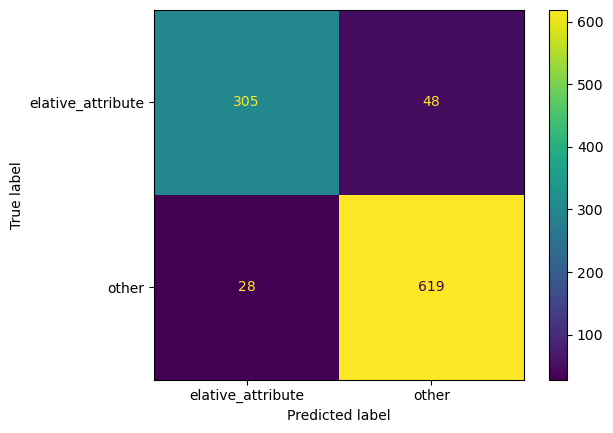

In [13]:
gpt1_1 = experiment1_1(annotator_1_df, model_results_df, 'gpt_1.1')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, ['elative_attribute', 'other'])

### gpt-5-5 (API)

accuracy 0.944
precision 0.9357283985691595
recall 0.9432070440604052
f1_macro 0.9392361111111112
f1_micro 0.944
f1_weighted 0.9442381944444445
f1_none [0.92222222 0.95625   ]


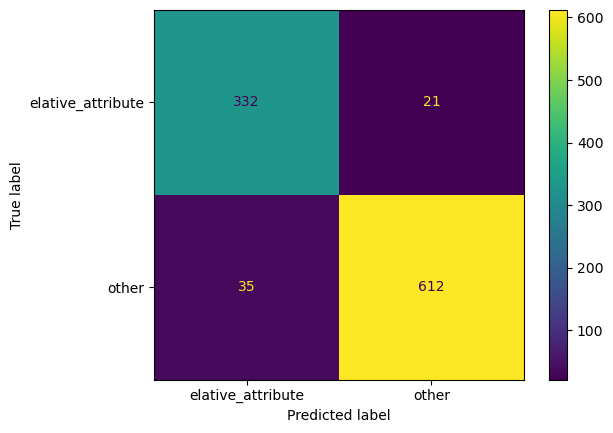

In [32]:
gpt1_1 = experiment1_1(annotator_1_df, model_results_df, 'gpt_1.1')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, ['elative_attribute', 'other'])

### DeepSeek Expert (chat)

accuracy 0.907
precision 0.9104020570359981
recall 0.8843627813705444
f1_macro 0.8950848966247796
f1_micro 0.907
f1_weighted 0.9054796752369897
f1_none [0.85972851 0.93044129]


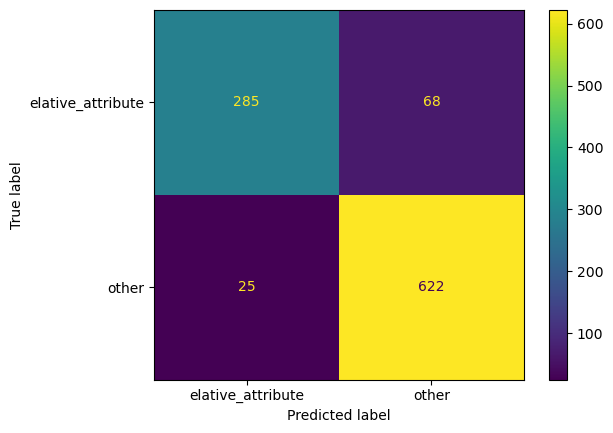

In [24]:
DS1_1 = experiment1_1(annotator_1_df, model_results_df, 'DS_1.1')
scores(annotator1_binary, DS1_1)
conf_matrix(annotator1_binary, DS1_1, ['elative_attribute', 'other'])

### DeepSeek V4 Pro (API, reasoning_effort=none) 

accuracy 0.877
precision 0.8676024955436721
recall 0.861178855559107
f1_macro 0.8642010883785941
f1_micro 0.877
f1_weighted 0.876458026543719
f1_none [0.82251082 0.90589135]


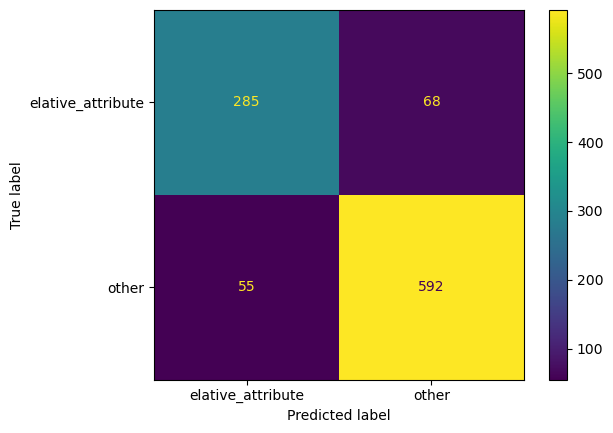

In [33]:
DS1_1 = experiment1_1(annotator_1_df, model_results_df, 'deep_1.1')
scores(annotator1_binary, DS1_1)
conf_matrix(annotator1_binary, DS1_1, ['elative_attribute', 'other'])

### Gemini-3.1-Pro (API)

accuracy 0.893
precision 0.8978571428571429
recall 0.8658200191776384
f1_macro 0.8783525524931474
f1_micro 0.893
f1_weighted 0.8907627817929015
f1_none [0.83614089 0.92056422]


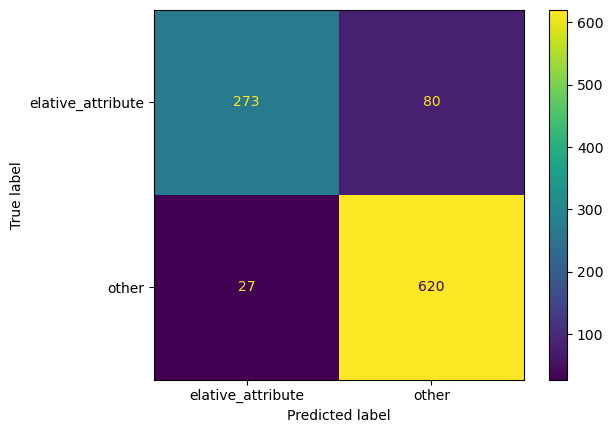

In [42]:
gem1_1 = experiment1_1(annotator_1_df, model_results_df, 'gem_1.1')
scores(annotator1_binary, gem1_1)
conf_matrix(annotator1_binary, gem1_1, ['elative_attribute', 'other'])

### Claude-Opus-4.7 (API)

accuracy 0.905
precision 0.9045036764705883
recall 0.8853917185878604
f1_macro 0.8936254788253117
f1_micro 0.905
f1_weighted 0.9038521125420038
f1_none [0.85884101 0.92840995]


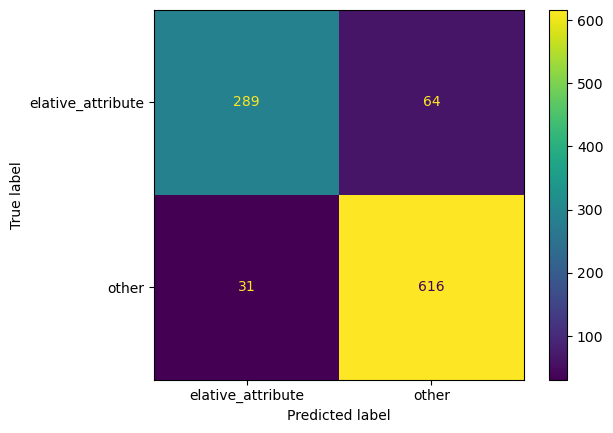

In [11]:
opus1_1 = experiment1_1(annotator_1_df, model_results_df, 'opus_1.1')
scores(annotator1_binary, opus1_1)
conf_matrix(annotator1_binary, opus1_1, ['elative_attribute', 'other'])

### Gemma-4-31B-it (API) iteration 1

accuracy 0.897
precision 0.89349820684131
recall 0.878565705303624
f1_macro 0.8851675494643567
f1_micro 0.897
f1_weighted 0.8960047471512076
f1_none [0.84830633 0.92202877]


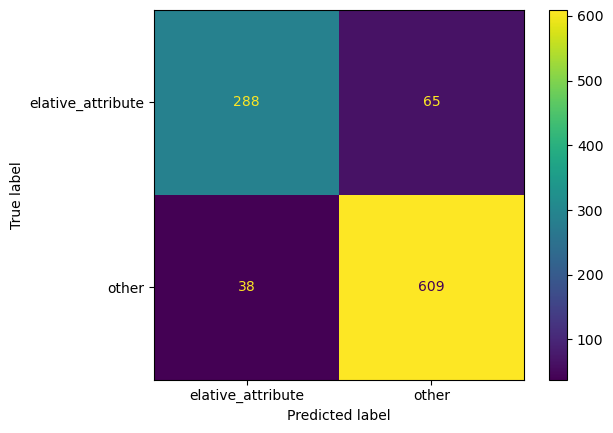

In [43]:
gemma1_1 = experiment1_1(annotator_1_df, model_results_df, 'gemma_1.1')
scores(annotator1_binary, gemma1_1)
conf_matrix(annotator1_binary, gemma1_1, ['elative_attribute', 'other'])

### Gemma-4-31B-it (API) iteration 2

accuracy 0.896
precision 0.8932414449103905
recall 0.8765056416408703
f1_macro 0.883801998605624
f1_micro 0.896
f1_weighted 0.8948705554264466
f1_none [0.84615385 0.92145015]


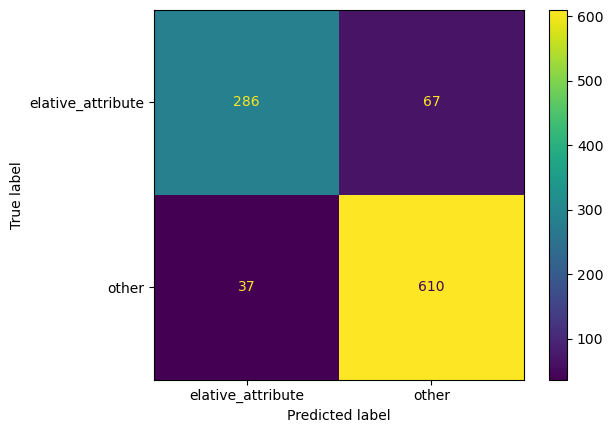

In [34]:
gemma1_1 = experiment1_1(annotator_1_df, model_results_df, 'gemma_1.1')
scores(annotator1_binary, gemma1_1)
conf_matrix(annotator1_binary, gemma1_1, ['elative_attribute', 'other'])

### Mistral-Large-2411 (API) 

accuracy 0.774
precision 0.7530467960947145
recall 0.7468245246091133
f1_macro 0.7496277651730006
f1_micro 0.774
f1_weighted 0.7725939095292116
f1_none [0.67151163 0.8277439 ]


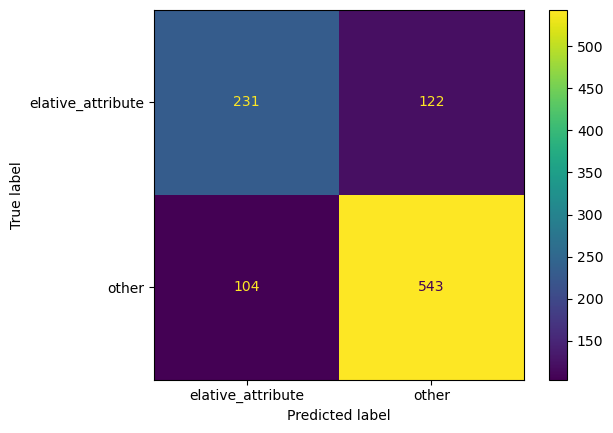

In [13]:
mist1_1 = experiment1_1(annotator_1_df, model_results_df, 'mist_1.1')
scores(annotator1_binary, mist1_1)
conf_matrix(annotator1_binary, mist1_1, ['elative_attribute', 'other'])

### tartuNLP/Llama-3.1-EstLLM-8B-Instruct-1125 (API)

accuracy 0.791
precision 0.7758261933904529
recall 0.7960055343686923
f1_macro 0.7806720669611328
f1_micro 0.791
f1_weighted 0.7946647504331464
f1_none [0.73307791 0.82826623]


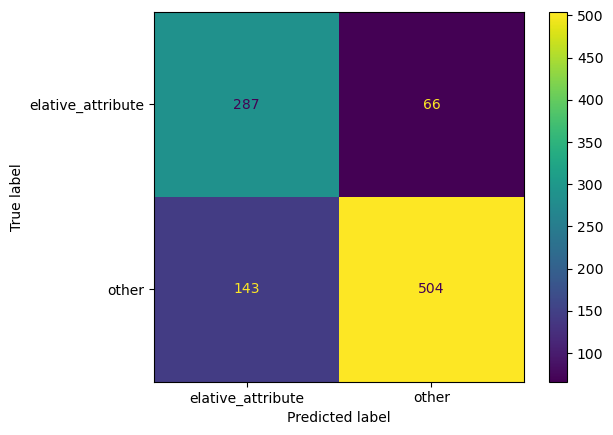

In [14]:
est1_1 = experiment1_1(annotator_1_df, model_results_df, 'est_1.1')
scores(annotator1_binary, est1_1)
conf_matrix(annotator1_binary, est1_1, ['elative_attribute', 'other'])

### meta-llama/llama-3.3-70b-instruct (API) 

accuracy 0.811
precision 0.8002380952380952
recall 0.7760616661777391
f1_macro 0.7851274058056529
f1_micro 0.811
f1_weighted 0.8070482781201718
f1_none [0.71056662 0.8596882 ]


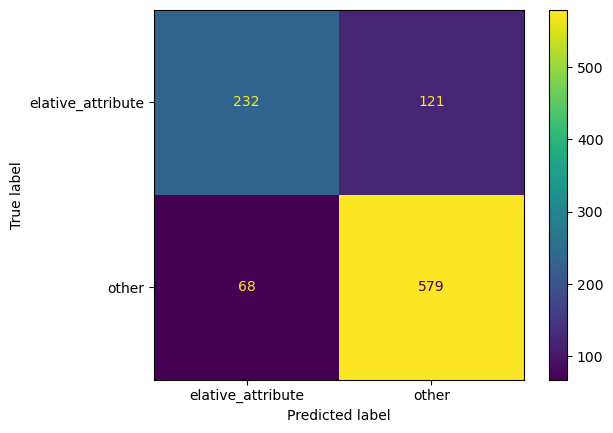

In [15]:
llama1_1 = experiment1_1(annotator_1_df, model_results_df, 'llama_1.1')
scores(annotator1_binary, llama1_1)
conf_matrix(annotator1_binary, llama1_1, ['elative_attribute', 'other'])

## Experiment 1_2: material

In [44]:
#combine gold standard labels into two values: elative_attribute and other
annotator1_binary = []
annotator1 = list(annotator_1_df['manual_annotation'])
for label in annotator1:
    if label in ['elative_attribute', 'other', 'error']:
        annotator1_binary.append('other')
    else:
        annotator1_binary.append('elative_material')

### GPT-5.5 (chat)

accuracy 0.982
precision 0.9527281339073508
recall 0.9701947487240752
f1_macro 0.9612216055978766
f1_micro 0.982
f1_weighted 0.9821703147082141
f1_none [0.93283582 0.98960739]


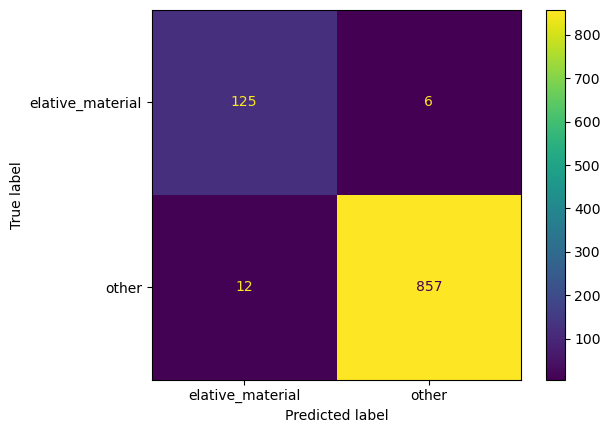

In [45]:
gpt1_1 = experiment1_2(annotator_1_df, model_results_df, 'gpt_1.2')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, ['elative_material', 'other'])

### GPT-5.5 (API)

accuracy 0.977
precision 0.9345794392523364
recall 0.970559298658632
f1_macro 0.9515151515151515
f1_micro 0.977
f1_weighted 0.9774569696969696
f1_none [0.91636364 0.98666667]


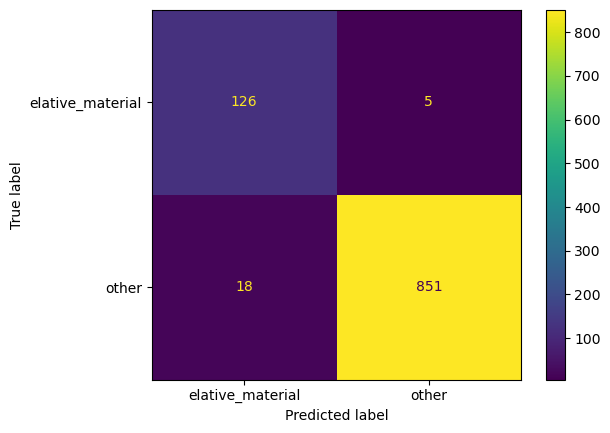

In [36]:
gpt1_1 = experiment1_2(annotator_1_df, model_results_df, 'gpt_1.2')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, ['elative_material', 'other'])

### DeepSeek Expert (chat)

accuracy 0.969
precision 0.9202288322006631
recall 0.9497492072136966
f1_macro 0.934248341891654
f1_micro 0.969
f1_weighted 0.9695258160098924
f1_none [0.88644689 0.9820498 ]


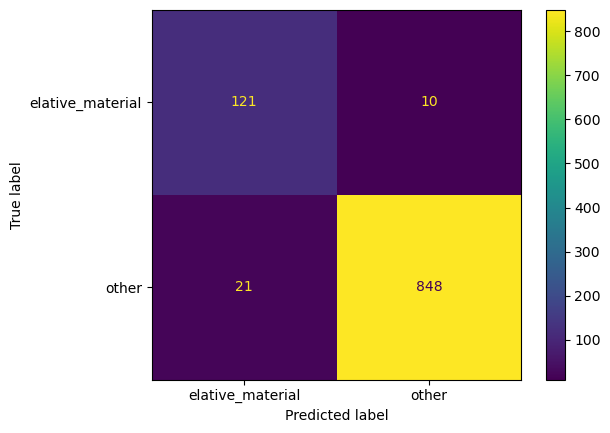

In [20]:
DS1_1 = experiment1_2(annotator_1_df, model_results_df, 'DS_1.2')
scores(annotator1_binary, DS1_1)
conf_matrix(annotator1_binary, DS1_1, ['elative_material', 'other'])

### DeepSeek V4 Pro (API)

accuracy 0.973
precision 0.9326053330643262
recall 0.9520507031860785
f1_macro 0.9420151662554039
f1_micro 0.973
f1_weighted 0.9732967083942712
f1_none [0.89962825 0.98440208]


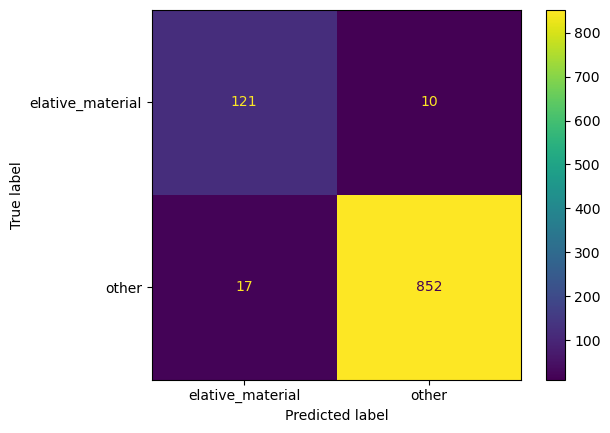

In [37]:
DS1_1 = experiment1_2(annotator_1_df, model_results_df, 'deep_1.2')
scores(annotator1_binary, DS1_1)
conf_matrix(annotator1_binary, DS1_1, ['elative_material', 'other'])

### Gemini-3.1-Pro

accuracy 0.98
precision 0.9461559672122928
recall 0.9690440007378842
f1_macro 0.9571826161421537
f1_micro 0.98
f1_weighted 0.9802500535217298
f1_none [0.92592593 0.98843931]


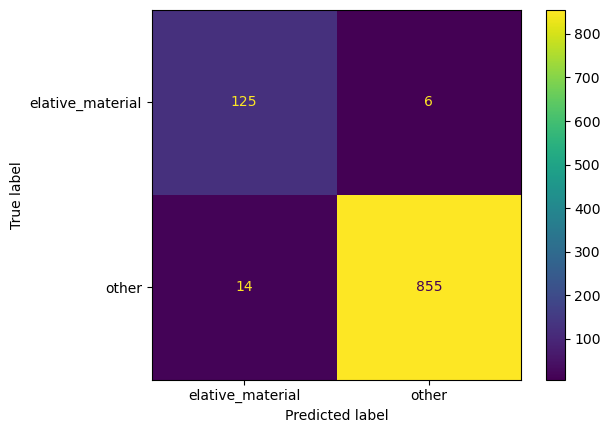

In [21]:
gem1_1 = experiment1_2(annotator_1_df, model_results_df, 'gem_1.2')
scores(annotator1_binary, gem1_1)
conf_matrix(annotator1_binary, gem1_1, ['elative_material', 'other'])

### Claude-Opus-4.7

accuracy 0.974
precision 0.9294824195640998
recall 0.962350336879277
f1_macro 0.9450228789403794
f1_micro 0.974
f1_weighted 0.9744789606786715
f1_none [0.90510949 0.98493627]


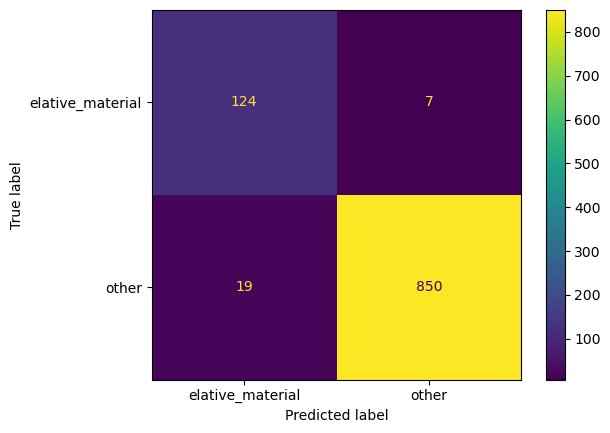

In [25]:
opus1_1 = experiment1_2(annotator_1_df, model_results_df, 'opus_1.2')
scores(annotator1_binary, opus1_1)
conf_matrix(annotator1_binary, opus1_1, ['elative_material', 'other'])

### Gemma-4-31B-it (iteration 1)

accuracy 0.97
precision 0.9252667552369254
recall 0.9470831613067578
f1_macro 0.9357739242132306
f1_micro 0.97
f1_weighted 0.9703750802825947
f1_none [0.88888889 0.98265896]


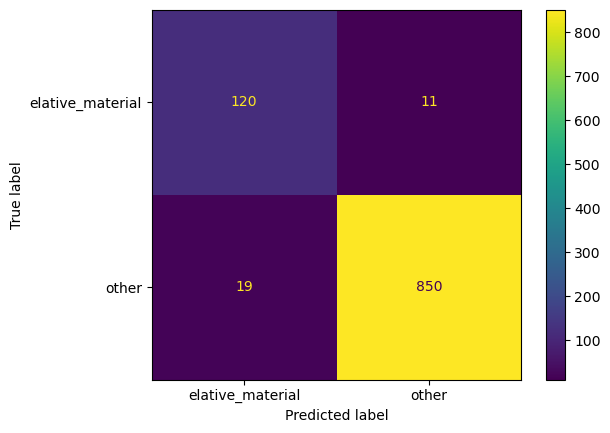

In [24]:
gemma1_1 = experiment1_2(annotator_1_df, model_results_df, 'gemma_1.2')
scores(annotator1_binary, gemma1_1)
conf_matrix(annotator1_binary, gemma1_1, ['elative_material', 'other'])

### Gemma-4-31B-it (iteration 2)

accuracy 0.968
precision 0.9191291209471677
recall 0.9459324133205668
f1_macro 0.931917211328976
f1_micro 0.968
f1_weighted 0.9684956427015251
f1_none [0.88235294 0.98148148]


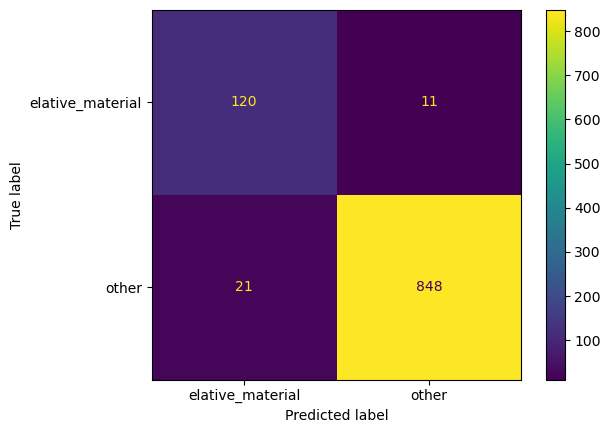

In [38]:
gemma1_1 = experiment1_2(annotator_1_df, model_results_df, 'gemma_1.2')
scores(annotator1_binary, gemma1_1)
conf_matrix(annotator1_binary, gemma1_1, ['elative_material', 'other'])

### Mistral-Large_2411

accuracy 0.964
precision 0.9305466714872395
recall 0.9079752984478079
f1_macro 0.918824579917201
f1_micro 0.964
f1_weighted 0.9635155450929458
f1_none [0.85826772 0.97938144]


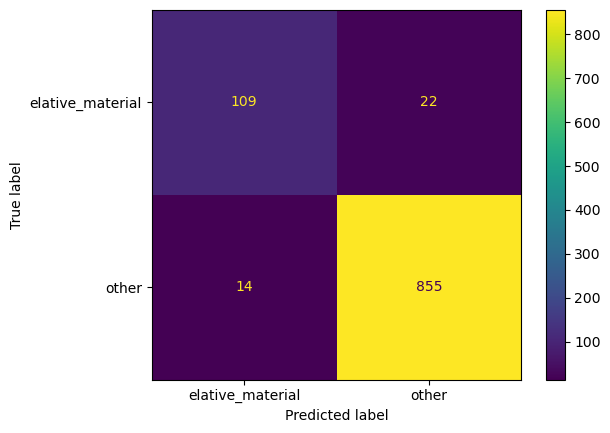

In [26]:
mist1_1 = experiment1_2(annotator_1_df, model_results_df, 'mist_1.2')
scores(annotator1_binary, mist1_1)
conf_matrix(annotator1_binary, mist1_1, ['elative_material', 'other'])

### tartuNLP

accuracy 0.95
precision 0.8646336434357766
recall 0.9582656207450873
f1_macro 0.903022591857001
f1_micro 0.95
f1_weighted 0.9528348435948363
f1_none [0.83552632 0.97051887]


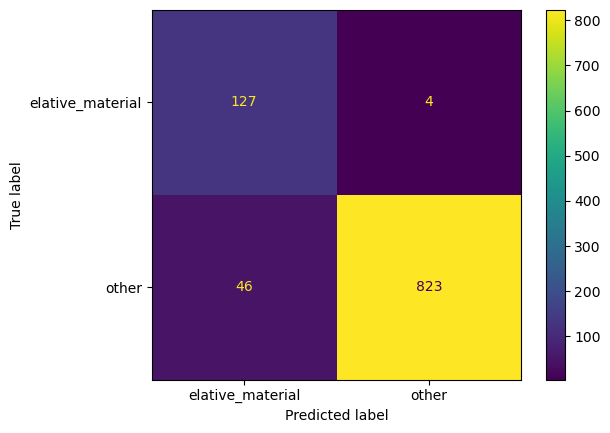

In [27]:
est1_1 = experiment1_2(annotator_1_df, model_results_df, 'est_1.2')
scores(annotator1_binary, est1_1)
conf_matrix(annotator1_binary, est1_1, ['elative_material', 'other'])

### meta-llama

accuracy 0.966
precision 0.9113934260939706
recall 0.94802308523441
f1_macro 0.9285450082383402
f1_micro 0.966
f1_weighted 0.9667242677964963
f1_none [0.87681159 0.98027842]


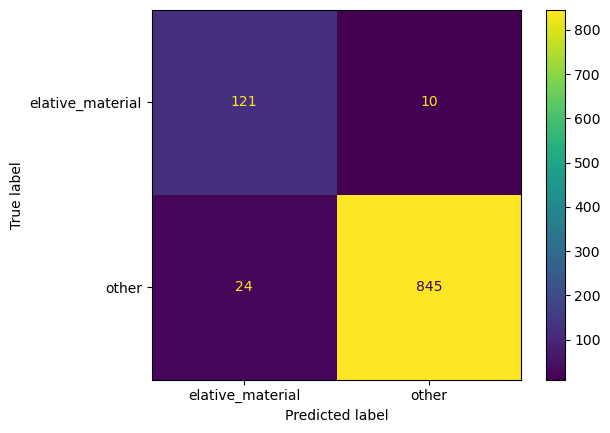

In [28]:
llama1_1 = experiment1_2(annotator_1_df, model_results_df, 'llama_1.2')
scores(annotator1_binary, llama1_1)
conf_matrix(annotator1_binary, llama1_1, ['elative_material', 'other'])

## Experiment 1 combined

In [72]:
#combine gold standard labels into three values: elative_attribute, elative_material and other
annotator1_binary = []
annotator1 = list(annotator_1_df['manual_annotation'])
for label in annotator1:
    if label in ['other', 'error']:
        annotator1_binary.append('other')
    elif label == 'elative_attribute':
        annotator1_binary.append('elative_attribute')
    elif label == 'elative_material':
        annotator1_binary.append('elative_material')

### gpt-5.5 (chat)

accuracy 0.906
precision 0.9088126275290578
recall 0.9135672521089999
f1_macro 0.9107274973653658
f1_micro 0.906
f1_weighted 0.9057226839147113
f1_none [0.88921283 0.93283582 0.91013384]


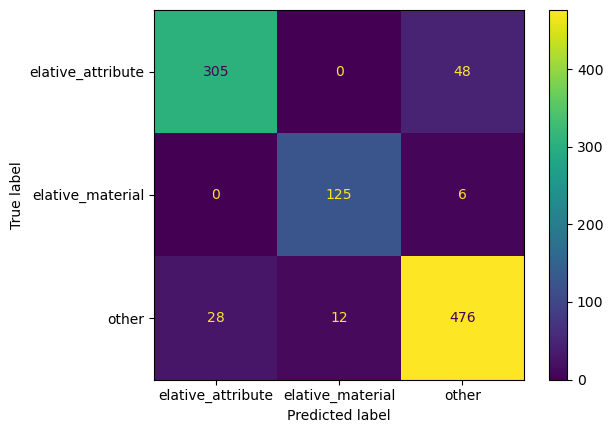

In [48]:
gpt1_1 = experiment1_big(annotator_1_df, model_results_df, 'gpt_1.1', 'gpt_1.2')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])

### gpt-5.5 (API)

In [55]:
#combine LLM and manual annotation for comparison
gpt1_1 = experiment1_big(annotator_1_df, model_results_df, 'gpt_1.1', 'gpt_1.2')
annotator_1_df['gpt1_1'] = gpt1_1
annotator_1_df.to_csv("gpt5.5_human_comparison.csv", header=True, index=False)

accuracy 0.921
precision 0.9088208061457422
recall 0.9332095992627644
f1_macro 0.9199929644705764
f1_micro 0.921
f1_weighted 0.9210268867782302
f1_none [0.92222222 0.91636364 0.92139303]


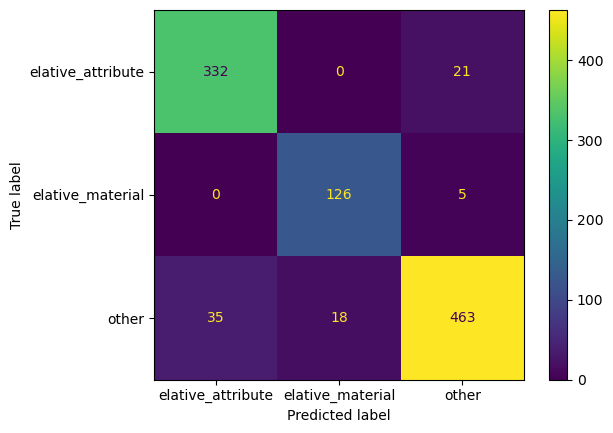

In [54]:
gpt1_1 = experiment1_big(annotator_1_df, model_results_df, 'gpt_1.1', 'gpt_1.2')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])

### DeepSeek Expert (chat)

accuracy 0.877
precision 0.8769855219536353
recall 0.8812734196351025
f1_macro 0.8771712463662928
f1_micro 0.877
f1_weighted 0.8764432914866351
f1_none [0.85972851 0.88644689 0.88533835]


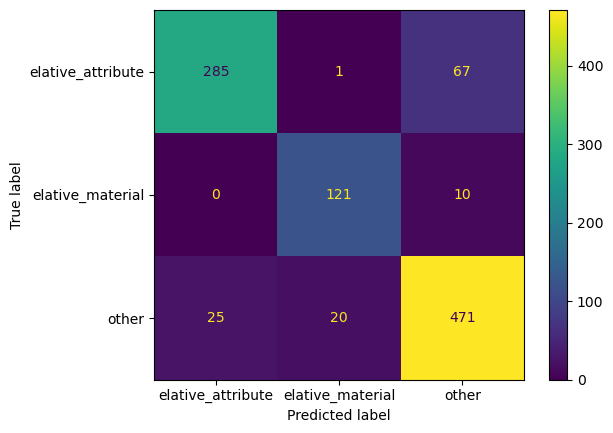

In [49]:
DS1_1 = experiment1_big(annotator_1_df, model_results_df, 'DS_1.1', 'DS_1.2')
scores(annotator1_binary, DS1_1)
conf_matrix(annotator1_binary, DS1_1, ['elative_attribute', 'elative_material', 'other'])

### DeepSeek V4 Pro

accuracy 0.852
precision 0.8564843395295817
recall 0.865123548834069
f1_macro 0.8604946564419672
f1_micro 0.852
f1_weighted 0.8516195867794811
f1_none [0.82251082 0.89962825 0.85934489]


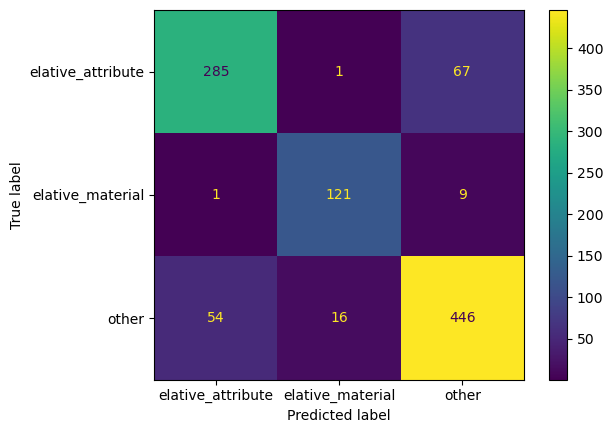

In [14]:
DS1_1 = experiment1_big(annotator_1_df, model_results_df, 'deep_1.1', 'deep_1.2')
scores(annotator1_binary, DS1_1)
conf_matrix(annotator1_binary, DS1_1, ['elative_attribute', 'elative_material', 'other'])

### Gemini-3.1-pro

accuracy 0.873
precision 0.8853276309433736
recall 0.8827040712524071
f1_macro 0.8813822218577928
f1_micro 0.873
f1_weighted 0.8716072331764337
f1_none [0.83614089 0.92592593 0.88207985]


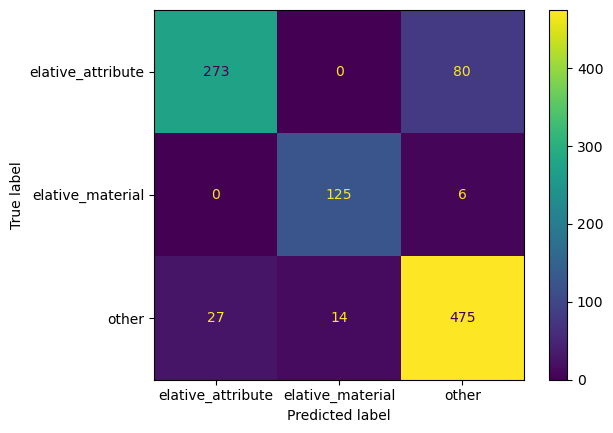

In [19]:
gem1_1 = experiment1_big(annotator_1_df, model_results_df, 'gem_1.1', 'gem_1.2')
scores(annotator1_binary, gem1_1)
conf_matrix(annotator1_binary, gem1_1, ['elative_attribute', 'elative_material', 'other'])

### Claude-Opus-4.7

accuracy 0.88
precision 0.8799680165427372
recall 0.8901001763462656
f1_macro 0.8836466843695012
f1_micro 0.88
f1_weighted 0.8794268294239228
f1_none [0.85884101 0.90510949 0.88698955]


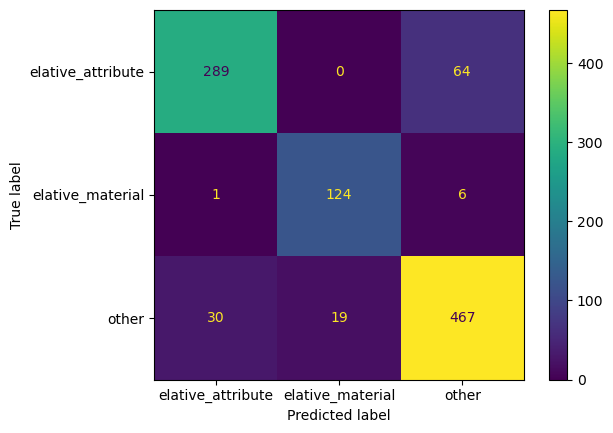

In [41]:
opus1_1 = experiment1_big(annotator_1_df, model_results_df, 'opus_1.1', 'opus_1.2')
scores(annotator1_binary, opus1_1)
conf_matrix(annotator1_binary, opus1_1, ['elative_attribute', 'elative_material', 'other'])

### Gemma-4-31B-it (iteration 1)

accuracy 0.87
precision 0.8700987790697434
recall 0.8757477980744456
f1_macro 0.872119307973232
f1_micro 0.87
f1_weighted 0.8695445342670273
f1_none [0.84830633 0.88888889 0.8791627 ]


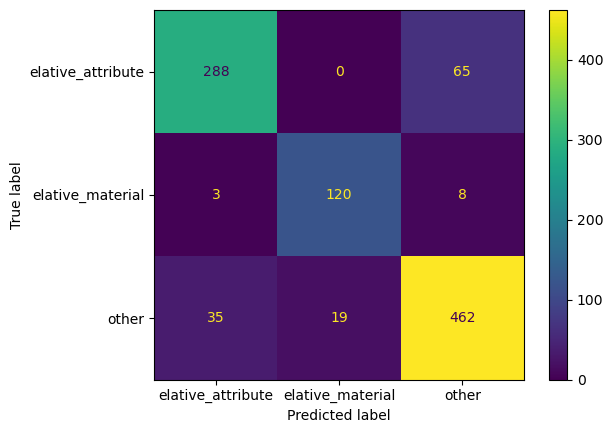

In [50]:
gemma1_1 = experiment1_big(annotator_1_df, model_results_df, 'gemma_1.1', 'gemma_1.2')
scores(annotator1_binary, gemma1_1)
conf_matrix(annotator1_binary, gemma1_1, ['elative_attribute', 'elative_material', 'other'])

### Gemma-4-31B-it (iteration 2)

accuracy 0.866
precision 0.8649072338065945
recall 0.8725672342838285
f1_macro 0.8676771673864048
f1_micro 0.866
f1_weighted 0.8655352958381364
f1_none [0.84615385 0.88235294 0.87452471]


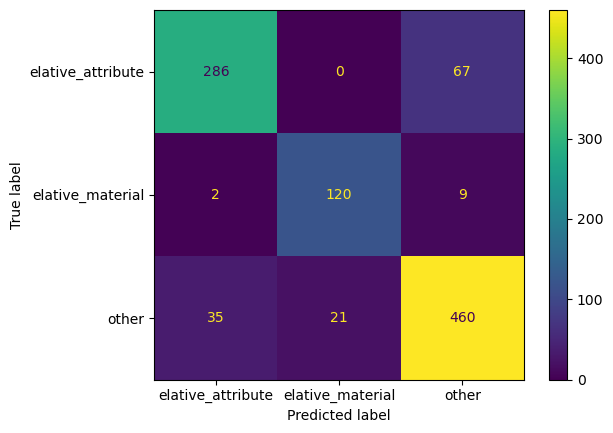

In [16]:
gemma1_1 = experiment1_big(annotator_1_df, model_results_df, 'gemma_1.1', 'gemma_1.2')
scores(annotator1_binary, gemma1_1)
conf_matrix(annotator1_binary, gemma1_1, ['elative_attribute', 'elative_material', 'other'])

### Mistral-Large-2411

accuracy 0.745
precision 0.7743211909731037
recall 0.7571119081589051
f1_macro 0.7651249358601353
f1_micro 0.745
f1_weighted 0.7445239344965104
f1_none [0.67151163 0.85826772 0.76559546]


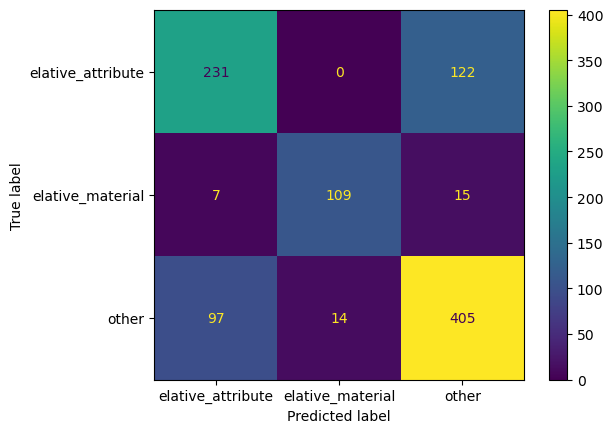

In [43]:
mist1_1 = experiment1_big(annotator_1_df, model_results_df, 'mist_1.1', 'mist_1.2')
scores(annotator1_binary, mist1_1)
conf_matrix(annotator1_binary, mist1_1, ['elative_attribute','elative_material', 'other'])

### tartunlp

accuracy 0.743
precision 0.7434204239823953
recall 0.8066979031842854
f1_macro 0.7631017356807996
f1_micro 0.743
f1_weighted 0.7401121566597836
f1_none [0.73307791 0.83552632 0.72070099]


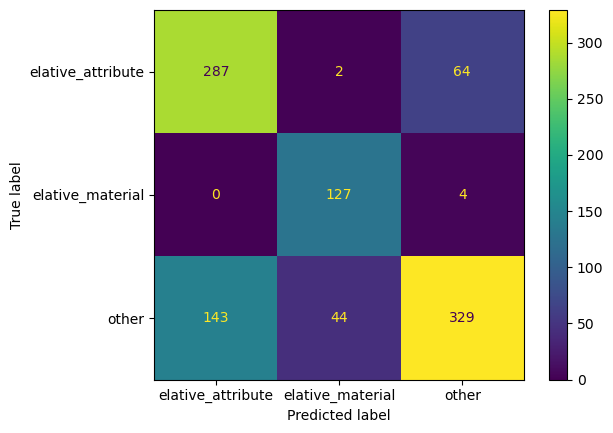

In [44]:
est1_1 = experiment1_big(annotator_1_df, model_results_df, 'est_1.1', 'est_1.2')
scores(annotator1_binary, est1_1)
conf_matrix(annotator1_binary, est1_1, ['elative_attribute', 'elative_material', 'other'])

### meta-llama

accuracy 0.78
precision 0.7923951537744641
recall 0.8028024326721201
f1_macro 0.7949212769127151
f1_micro 0.78
f1_weighted 0.7771433145466723
f1_none [0.71056662 0.87681159 0.79738562]


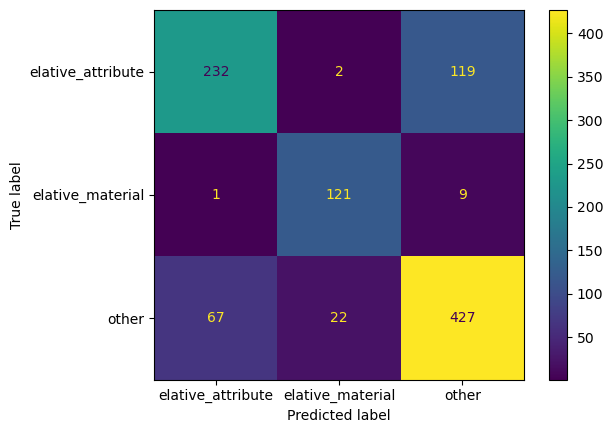

In [45]:
llama1_1 = experiment1_big(annotator_1_df, model_results_df, 'llama_1.1', 'llama_1.2')
scores(annotator1_binary, llama1_1)
conf_matrix(annotator1_binary, llama1_1, ['elative_attribute', 'elative_material', 'other'])

# Experiment 2: word annotation in context

In [10]:
#combine gold standard labels into three values: elative_attribute, elative_material and other
annotator1_binary = []
annotator1 = list(annotator_1_df['manual_annotation'])
for label in annotator1:
    if label in ['other', 'error']:
        annotator1_binary.append('other')
    elif label == 'elative_attribute':
        annotator1_binary.append('elative_attribute')
    elif label == 'elative_material':
        annotator1_binary.append('elative_material')

## instance_lemma

In [14]:
gpt1_1 = experiment2_big(annotator_1_df, model_results_df, 'gpt_2.1', 'gpt_2.5', 'instance_lemma')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

## instance_form

accuracy 0.873
precision 0.8980884316648553
recall 0.8739167646073228
f1_macro 0.8828052954565102
f1_micro 0.873
f1_weighted 0.871522620723368
f1_none [0.83024691 0.93436293 0.88380604]


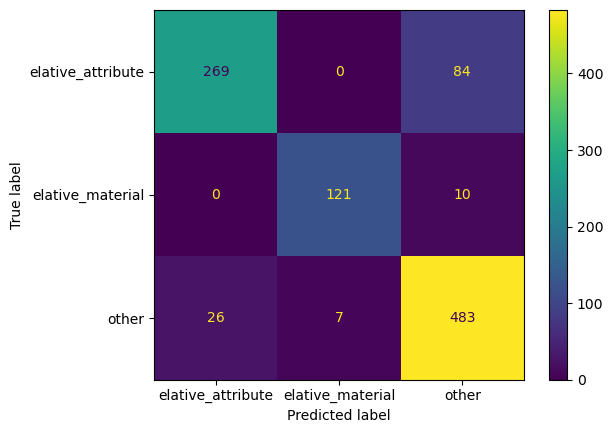

In [49]:
gpt1_1 = experiment2_big(annotator_1_df, model_results_df, 'gpt_2.2', 'gpt_2.6', 'instance_form')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])

## instance_form_long

In [81]:
gpt1_1 = experiment2_big(annotator_1_df, model_results_df, 'gpt_2.3', 'gpt_2.7', 'instance_form_long')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])

KeyError: 'tähetargast treener miroslav blazevic : " mm-i finaalis kohtuvad horvaatia ja prantsusmaa "'

## sentence

accuracy 0.901
precision 0.9226300222647591
recall 0.9030694833566821
f1_macro 0.9109489406872292
f1_micro 0.901
f1_weighted 0.9001679852511942
f1_none [0.86706949 0.95752896 0.90824838]


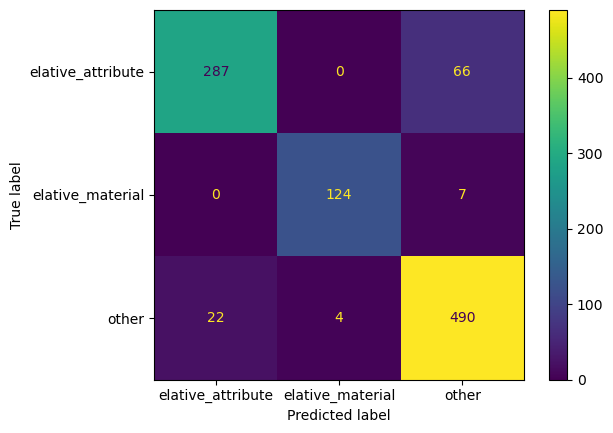

In [79]:
gpt1_1 = experiment2_big(annotator_1_df, model_results_df, 'gpt_2.4', 'gpt_2.8', 'sentence')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])

# Experiment 3: annotation by definition

## Experiment 3: elative_attribute

In [12]:
#combine gold standard labels into two values: elative_attribute and other
annotator1_binary = []
annotator1 = list(annotator_1_df['manual_annotation'])
for label in annotator1:
    if label in ['elative_material', 'other', 'error']:
        annotator1_binary.append('other')
    else:
        annotator1_binary.append('elative_attribute')

### instance_lemma

accuracy 0.926
precision 0.9136104216799164
recall 0.9312275877771015
f1_macro 0.9208102184781863
f1_micro 0.926
f1_weighted 0.9267703581946442
f1_none [0.90053763 0.9410828 ]


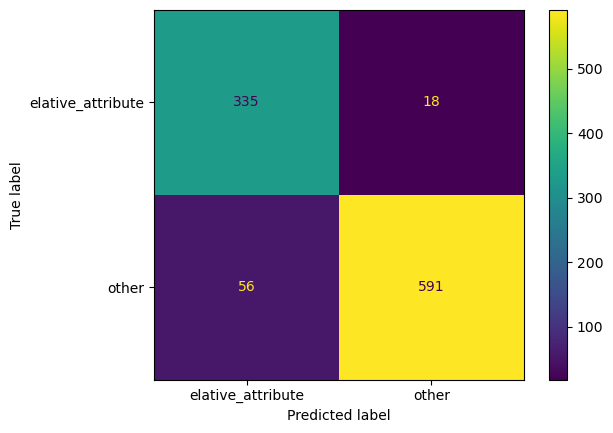

In [87]:
gpt1_1 = experiment3_small(annotator_1_df, model_results_df, 'gpt_3.1', 'instance_lemma')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'other'])

### instance_form

accuracy 0.929
precision 0.9168348045397225
recall 0.9341896134260983
f1_macro 0.9239788811190308
f1_micro 0.929
f1_weighted 0.9297228848194392
f1_none [0.90444145 0.94351631]


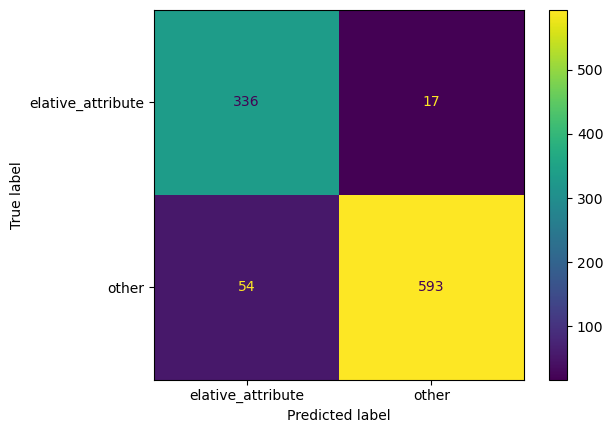

In [88]:
gpt1_1 = experiment3_small(annotator_1_df, model_results_df, 'gpt_3.2', 'instance_form')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'other'])

### instance_form+sentence

### instance_form_long

accuracy 0.927
precision 0.9150605053079273
recall 0.9307131191684436
f1_macro 0.9216636494652203
f1_micro 0.927
f1_weighted 0.9276747109871561
f1_none [0.90121786 0.94210944]


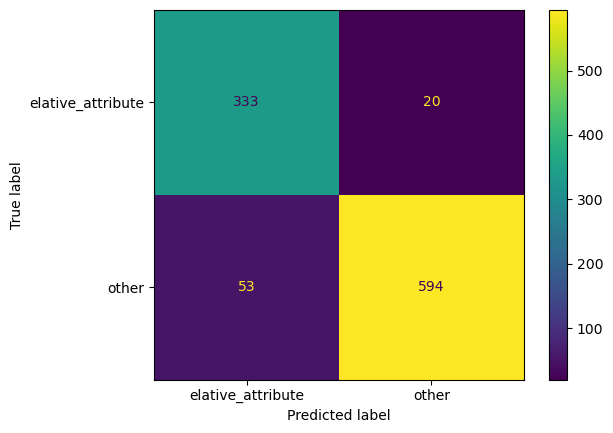

In [91]:
gpt1_1 = experiment3_small(annotator_1_df, model_results_df, 'gpt_3.3', 'instance_form_long')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'other'])

### instance_form_long+sentence

accuracy 0.913
precision 0.8999060150375939
recall 0.9173194215183611
f1_macro 0.9069493836733602
f1_micro 0.913
f1_weighted 0.9139253883793684
f1_none [0.88322148 0.93067729]


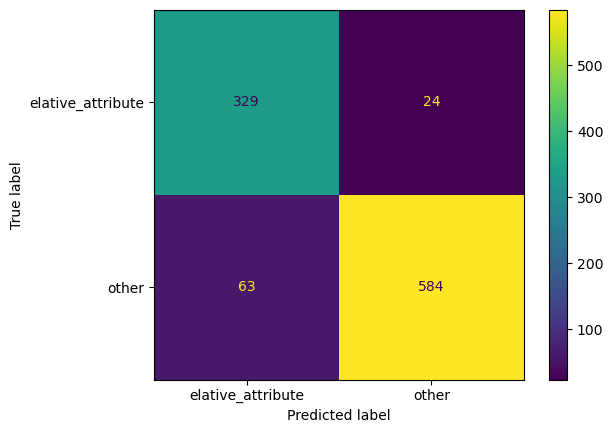

In [93]:
gpt1_1 = experiment3_small(annotator_1_df, model_results_df, 'gpt_3.4', 'sentence')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'other'])

## Experiment 3 combined

In [84]:
#combine gold standard labels into three values: elative_attribute, elative_material and other
annotator1_binary = []
annotator1 = list(annotator_1_df['manual_annotation'])
for label in annotator1:
    if label in ['other', 'error']:
        annotator1_binary.append('other')
    elif label == 'elative_attribute':
        annotator1_binary.append('elative_attribute')
    elif label == 'elative_material':
        annotator1_binary.append('elative_material')

### instance_form_long+sentence

accuracy 0.9
precision 0.9077434003904591
recall 0.9168502966661732
f1_macro 0.9109951223674958
f1_micro 0.9
f1_weighted 0.900285767004693
f1_none [0.88322148 0.95057034 0.89919355]


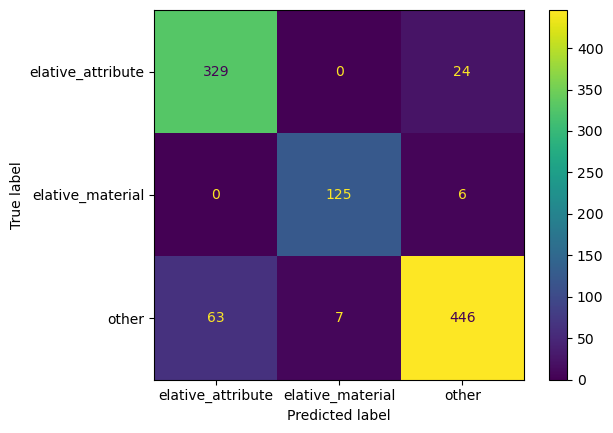

In [83]:
gpt1_1 = experiment2_big(annotator_1_df, model_results_df, 'gpt_3.4', 'gpt_3.5', 'sentence')
scores(annotator1_binary, gpt1_1)
conf_matrix(annotator1_binary, gpt1_1, labels=['elative_attribute', 'elative_material', 'other'])